In [115]:
##importing packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import ttest_ind
import statsmodels.formula.api as smf




In [116]:
#importing our dataset

hw_2_data = pd.read_csv("SCCS2_v12.csv")

print(hw_2_data.head())
print(hw_2_data.columns.tolist())
print(hw_2_data["gender"].value_counts())  
print(hw_2_data.isna().sum())

FileNotFoundError: [Errno 2] No such file or directory: 'SCCS2_v12.csv'

In [ ]:
#problem 1 wants us to adjust for linnear and quadratic age, so lets create that quadratic age column first
#remember we also have to create our bmi colummn like last time

hw_2_data["age_squared"] = hw_2_data["age"] ** 2


height_meters = hw_2_data["height"] / 100
hw_2_data["bmi"] = hw_2_data["weight"] / (height_meters ** 2)

analytic = hw_2_data.dropna(subset=["tc", "gender", "bmi", "age"])



In [ ]:
#ok now that we got our colmns made and our nice suset created, lets look at the models

# Model 1
y_total_cholesteral = analytic["tc"]

X1 = sm.add_constant(analytic[["gender", "age", "age_squared"]])
m1 = sm.OLS(y_total_cholesteral, X1).fit()

#now for our second model, lets add in BMI to see if it is a confounder

# Model 2
X2 = sm.add_constant(analytic[["gender", "age", "age_squared", "bmi"]])
m2 = sm.OLS(y_total_cholesteral, X2).fit()

print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:                     tc   R-squared:                       0.166
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     25.99
Date:                Thu, 24 Sep 2026   Prob (F-statistic):           1.15e-19
Time:                        21:09:20   Log-Likelihood:                -724.97
No. Observations:                 527   AIC:                             1460.
Df Residuals:                     522   BIC:                             1481.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.6224      0.414      6.335      

In [119]:
#Ok now we are making our third model. This time comparing bmi coefficnet before vs after gender is added
X3 = sm.add_constant(analytic[["bmi", "age", "age_squared"]])
m3 = sm.OLS(y_total_cholesteral, X3).fit()


# adding model 4 even though it should have the exact same variables as model 2
X4 = sm.add_constant(analytic[["bmi", "age", "age_squared", "gender"]])
m4 = sm.OLS(y_total_cholesteral, X4).fit()
print(m4.summary())

                            OLS Regression Results                            
Dep. Variable:                     tc   R-squared:                       0.166
Model:                            OLS   Adj. R-squared:                  0.160
Method:                 Least Squares   F-statistic:                     25.99
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           1.15e-19
Time:                        21:03:50   Log-Likelihood:                -724.97
No. Observations:                 527   AIC:                             1460.
Df Residuals:                     522   BIC:                             1481.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.6224      0.414      6.335      

In [ ]:
#ok now we are moving onto effect modification
#first we have to multiply gender and BMI into our gender_bmi column to actullly produce effect modification
analytic["gender_bmi"] = analytic["gender"] * analytic["bmi"]

#now we can add it to our model
X5 = sm.add_constant(analytic[["gender", "bmi", "gender_bmi", "age", "age_squared"]])
m5 = sm.OLS(y_total_cholesteral, X5).fit()

# its way easier for my to visualize the effecct modifcation stuff if I can print out the two tables


b = m5.params

# Men gender 0
intercept_men = b["const"]
slope_men = b["bmi"]

# Women gender 1
intercept_women = b["const"] + b["gender"]
slope_women = b["bmi"] + b["gender_bmi"]

print(f"Men:   intercept = {intercept_men:.4f}, BMI slope = {slope_men:.4f}")
print(f"Women: intercept = {intercept_women:.4f}, BMI slope = {slope_women:.4f}")

Men:   intercept = 2.4450, BMI slope = 0.0374
Women: intercept = 2.8261, BMI slope = 0.0248


In [ ]:
# now we need to check out statsmodels to see how is is calculating standardized/ studentized residuals
#thankfully, statsmodels gives us super easy definitions to click through. Seems like we can just copy and paste them per the hws instructions

def get_resid_studentized_external(self, sigma=None):
    """
    Calculate studentized residuals

    Parameters
    ----------
    sigma : float, optional
        estimate of the standard deviation of the residuals. If None, then
        the estimate from the regression results is used.

    Returns
    -------
    stzd_resid : ndarray
        studentized residuals

    Notes
    -----
    studentized residuals are defined as ::

       resid / sigma / np.sqrt(1 - hii)

    where resid are the residuals from the regression, sigma is an
    estimate of the standard deviation of the residuals, and hii is the
    diagonal of the hat_matrix.
    """
    hii = self.hat_matrix_diag
    if sigma is None:
        sigma2_est = self.scale
        # can be replace by different estimators of sigma
        sigma = np.sqrt(sigma2_est)

    return self.resid / sigma / np.sqrt(1 - hii)

In [123]:
#now we are back to finding out hat values
# turns out statsmodels is the best and the the hat_matrix_diag to pull the hat vlaues



infl4 = m4.get_influence()
h = infl4.hat_matrix_diag
# we have to create a varaiable to show the number of obervations and coefficents
n = int(m4.nobs)
p = 4  


#for the next part, we need to see if our hat values are positive. I think theoretically they have to be.

print("Min hat value:", h.min())
print("All positive?", (h > 0).all())
print("(p + 1) / n:", (p + 1) / n)
print("Mean of hat values:", h.mean())
print("Difference:", h.mean() - (p + 1) / n)

Min hat value: 0.005042521258988121
All positive? True
(p + 1) / n: 0.009487666034155597
Mean of hat values: 0.0094876660341556
Difference: 3.469446951953614e-18


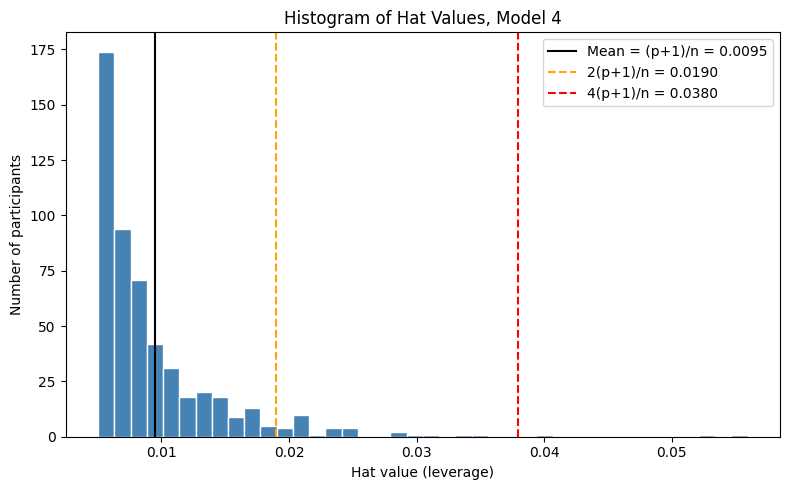

In [124]:
# ok now we need to make a histogram of our points
avg = (p + 1) / n
cut2 = 2 * (p + 1) / n 
cut4 = 4 * (p + 1) / n 

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(h, bins=40, color="steelblue", edgecolor="white")

ax.axvline(avg,  color="black",  linestyle="-",  label=f"Mean = (p+1)/n = {avg:.4f}")
ax.axvline(cut2, color="orange", linestyle="--", label=f"2(p+1)/n = {cut2:.4f}")
ax.axvline(cut4, color="red",    linestyle="--", label=f"4(p+1)/n = {cut4:.4f}")

ax.set_xlabel("Hat value (leverage)")
ax.set_ylabel("Number of participants")
ax.set_title("Histogram of Hat Values, Model 4")
ax.legend()
plt.tight_layout()
plt.savefig("hat_values_histogram.png", dpi=300)
plt.show()

In [ ]:
#now we need to see what points leverage twice the average

df = analytic[["age", "gender", "bmi"]].copy()
df["total_chol"] = y_total_cholesteral
df["hat"] = h

above2 = df[df["hat"] > cut2].sort_values("hat", ascending=False)
print(len(above2), "people above 2(p+1)/n =", round(cut2, 4))
print(above2.round(4).to_string())

32 people above 2(p+1)/n = 0.019
         age  gender      bmi  total_chol     hat
241  78.7433       0  23.1274        6.42  0.0559
162  78.2806       0  24.5259        4.76  0.0529
474  67.4853       1  40.4937        5.90  0.0403
476  69.2183       1  37.4004        4.94  0.0350
261  74.4695       0  22.5934        6.52  0.0332
272  73.2923       0  19.8188        4.43  0.0306
456  67.4004       1  37.1421        6.30  0.0301
362  53.8727       1  39.9846        6.24  0.0286
170  54.4559       0  39.5248        6.18  0.0281
440  40.4463       1  37.9683        5.72  0.0251
421  36.5886       1  37.5363        4.54  0.0250
454  70.3573       1  30.4846        7.90  0.0247
526  60.7091       1  38.0043        5.40  0.0242
345  68.4682       1  17.6651        5.80  0.0241
467  32.0767       1  36.4292        3.72  0.0238
459  38.4860       1  37.2765        5.14  0.0236
347  69.3415       1  19.2658        5.94  0.0234
424  48.8241       1  37.8121        5.89  0.0228
21   18.5599     

In [128]:
#now we need to see what points leverage 4x the average

# now we need to see which points have leverage 4x the average

df = analytic[["age", "gender", "bmi"]].copy()
df["total_chol"] = y_total_cholesteral
df["hat"] = h

above4 = df[df["hat"] > cut4].sort_values("hat", ascending=False)
print(len(above4), "people above 4(p+1)/n =", round(cut4, 4))
print(above4.round(4).to_string())



3 people above 4(p+1)/n = 0.038
         age  gender      bmi  total_chol     hat
241  78.7433       0  23.1274        6.42  0.0559
162  78.2806       0  24.5259        4.76  0.0529
474  67.4853       1  40.4937        5.90  0.0403


In [ ]:
#for the next question it is asking us about influence using our old friedns Cooks distance. Lets bring that in
#we also need to see if they are all positve, so lets add some code for that 
cooks_d = infl4.cooks_distance[0]
print("Number of Cook's distances:", len(cooks_d))
print("All positive?", (cooks_d > 0).all())

Number of Cook's distances: 527
All positive? True


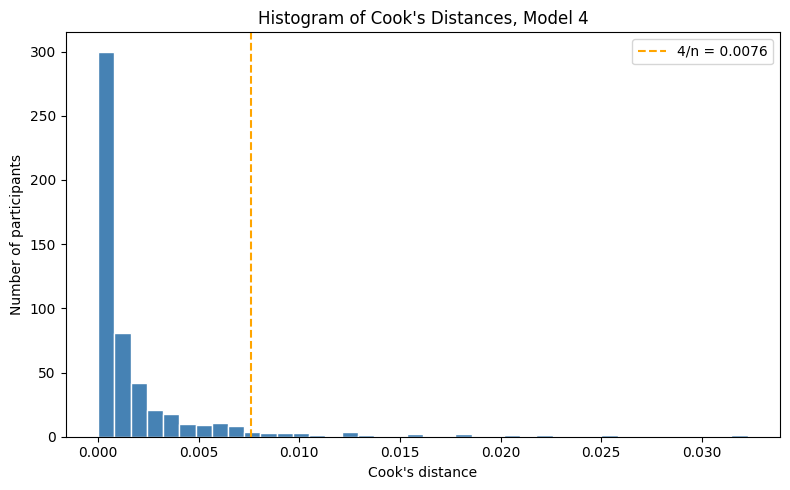

In [132]:
#now we are going to make a historgram to report our Cooks distances
cut_4n = 4 / n 

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(cooks_d, bins=40, color="steelblue", edgecolor="white")
ax.axvline(cut_4n, color="orange", linestyle="--", label=f"4/n = {cut_4n:.4f}")

ax.set_xlabel("Cook's distance")
ax.set_ylabel("Number of participants")
ax.set_title("Histogram of Cook's Distances, Model 4")
ax.legend()
plt.tight_layout()
plt.savefig("cooks_distance_histogram.png", dpi=300)
plt.show()

In [140]:
#now that we have our histogram. We need to find which people actually have the highest cook's distance
#first we need to do 4/n

df = analytic[["age", "gender", "bmi"]].copy()
df["total_chol"] = y_total_cholesteral
df["stud_resid"] = infl4.resid_studentized_internal
df["hat"] = h
df["cooks_d"] = cooks_d

cut_4n = 4 / n
cut_12n = 12 / n

# 4B(i): Cook's distance > 4/n
above_4n = df[df["cooks_d"] > cut_4n].sort_values("cooks_d", ascending=False)
print(len(above_4n), "people above 4/n =", round(cut_4n, 4))
print(above_4n.round(4).to_string())

24 people above 4/n = 0.0076
         age  gender      bmi  total_chol  stud_resid     hat  cooks_d
513  67.1266       1  24.6194        9.10      3.3013  0.0146   0.0323
102  54.5791       0  29.8380        9.93      4.1181  0.0074   0.0254
450  46.1903       1  25.9407        9.91      4.2789  0.0060   0.0222
467  32.0767       1  36.4292        3.72     -2.0706  0.0238   0.0209
42   20.7940       0  21.5668        7.07      2.5384  0.0140   0.0183
454  70.3573       1  30.4846        7.90      1.8930  0.0247   0.0182
458  38.6256       1  33.8748        3.70     -2.2438  0.0152   0.0155
476  69.2183       1  37.4004        4.94     -1.4564  0.0350   0.0154
98   68.6872       0  25.8064        3.90     -2.0905  0.0151   0.0134
497  56.2245       1  15.8812        7.48      1.9087  0.0174   0.0129
511  58.0890       1  29.4053        8.81      2.8500  0.0079   0.0129
24   63.5346       0  16.4023        3.78     -1.9402  0.0165   0.0126
162  78.2806       0  24.5259        4.76     -1

In [141]:
#now we need to find Cook's distance > 12/n
above_12n = df[df["cooks_d"] > cut_12n].sort_values("cooks_d", ascending=False)
print(len(above_12n), "people above 12/n =", round(cut_12n, 4))
print(above_12n.round(4).to_string())



2 people above 12/n = 0.0228
         age  gender      bmi  total_chol  stud_resid     hat  cooks_d
513  67.1266       1  24.6194        9.10      3.3013  0.0146   0.0323
102  54.5791       0  29.8380        9.93      4.1181  0.0074   0.0254


In [142]:
#now we have to use a differnt measure of influecne. We are going to use DFFITS
dffits_vals, dffits_cut = infl4.dffits
df["dffits"] = dffits_vals
df["stud_resid_ext"] = infl4.resid_studentized_external

print("DFFITS threshold 2*sqrt(k/n) =", round(dffits_cut, 4))

high_dffits = df[df["dffits"].abs() > dffits_cut].copy()
high_dffits = high_dffits.reindex(high_dffits["dffits"].abs().sort_values(ascending=False).index)
cols = ["age", "gender", "bmi", "total_chol", "stud_resid_ext", "hat", "cooks_d", "dffits"]
print(len(high_dffits), "people with |DFFITS| >", round(dffits_cut, 4))
print(high_dffits[cols].round(4).to_string())

DFFITS threshold 2*sqrt(k/n) = 0.1948
24 people with |DFFITS| > 0.1948
         age  gender      bmi  total_chol  stud_resid_ext     hat  cooks_d  dffits
513  67.1266       1  24.6194        9.10          3.3332  0.0146   0.0323  0.4056
102  54.5791       0  29.8380        9.93          4.1826  0.0074   0.0254  0.3617
450  46.1903       1  25.9407        9.91          4.3518  0.0060   0.0222  0.3386
467  32.0767       1  36.4292        3.72         -2.0771  0.0238   0.0209 -0.3243
42   20.7940       0  21.5668        7.07          2.5518  0.0140   0.0183  0.3043
454  70.3573       1  30.4846        7.90          1.8977  0.0247   0.0182  0.3022
458  38.6256       1  33.8748        3.70         -2.2525  0.0152   0.0155 -0.2795
476  69.2183       1  37.4004        4.94         -1.4580  0.0350   0.0154 -0.2776
98   68.6872       0  25.8064        3.90         -2.0973  0.0151   0.0134 -0.2596
511  58.0890       1  29.4053        8.81          2.8697  0.0079   0.0129  0.2556
497  56.2245    

In [143]:
#now we are flagging to see essentially if the exact same people show up across measures
cut_lev = 4 * (p + 1) / n
cut_cook = 12 / n

df["flag_resid"] = df["stud_resid"].abs() > 3
df["flag_lev"] = df["hat"] > cut_lev
df["flag_cook"] = df["cooks_d"] > cut_cook

print("Large residual (|r| > 3):", list(df.index[df["flag_resid"]]))
print("High leverage (> 4(p+1)/n):", list(df.index[df["flag_lev"]]))
print("High influence (> 12/n):", list(df.index[df["flag_cook"]]))

flagged = df[df["flag_resid"] | df["flag_lev"] | df["flag_cook"]]
cols = ["age", "gender", "bmi", "total_chol", "stud_resid", "hat", "cooks_d",
        "flag_resid", "flag_lev", "flag_cook"]
print(len(flagged), "unique flagged observations")
print(flagged[cols].round(4).to_string())

Large residual (|r| > 3): [102, 450, 513]
High leverage (> 4(p+1)/n): [162, 241, 474]
High influence (> 12/n): [102, 513]
6 unique flagged observations
         age  gender      bmi  total_chol  stud_resid     hat  cooks_d  flag_resid  flag_lev  flag_cook
102  54.5791       0  29.8380        9.93      4.1181  0.0074   0.0254        True     False       True
162  78.2806       0  24.5259        4.76     -1.0465  0.0529   0.0122       False      True      False
241  78.7433       0  23.1274        6.42      0.7813  0.0559   0.0072       False      True      False
450  46.1903       1  25.9407        9.91      4.2789  0.0060   0.0222        True     False      False
474  67.4853       1  40.4937        5.90     -0.5510  0.0403   0.0026       False      True      False
513  67.1266       1  24.6194        9.10      3.3013  0.0146   0.0323        True     False       True


In [144]:
#finally we need to refit the model w/out the 6 flagged observations
keep = ~(df["flag_resid"] | df["flag_lev"] | df["flag_cook"])
X4_red = X4[keep.values]
y_red = y_total_cholesteral[keep.values]
m4_red = sm.OLS(y_red, X4_red).fit()

print("n full:", int(m4.nobs), " n reduced:", int(m4_red.nobs))

import pandas as pd
comparison = pd.DataFrame({
    "coef_full": m4.params,
    "coef_reduced": m4_red.params,
    "pct_change": 100 * (m4_red.params - m4.params) / m4.params,
    "p_full": m4.pvalues,
    "p_reduced": m4_red.pvalues,
})
print(comparison.round(4))
print("R-squared full:", round(m4.rsquared, 4), " reduced:", round(m4_red.rsquared, 4))

n full: 527  n reduced: 521
             coef_full  coef_reduced  pct_change  p_full  p_reduced
const           2.6224        2.7165      3.5878  0.0000     0.0000
bmi             0.0299        0.0288     -3.5231  0.0037     0.0039
age             0.0792        0.0763     -3.6813  0.0000     0.0001
age_squared    -0.0006       -0.0006     -3.4794  0.0030     0.0045
gender          0.0774        0.0608    -21.5163  0.3616     0.4572
R-squared full: 0.1661  reduced: 0.166
